<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/kod/perplane_lrFinetune%3D5e_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seed   : {SEED}")

PyTorch: 2.11.0+cu128
Cihaz  : cuda
GPU    : NVIDIA A100-SXM4-40GB
Seed   : 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slice_v2/'
zip_cn   = drive_path + 'Slice_CN.zip'
zip_emci = drive_path + 'Slice_EMCI.zip'

local_dir = '/content/dataset'
os.makedirs(local_dir, exist_ok=True)

if not os.path.exists(os.path.join(local_dir, 'Slice_CN')):
    print("Slice_CN aciliyor...")
    shutil.unpack_archive(zip_cn, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_CN zaten var.")

if not os.path.exists(os.path.join(local_dir, 'Slice_EMCI')):
    print("Slice_EMCI aciliyor...")
    shutil.unpack_archive(zip_emci, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_EMCI zaten var.")

print("Veri hazir.")

Slice_CN aciliyor...
  Tamamlandi.
Slice_EMCI aciliyor...
  Tamamlandi.
Veri hazir.


In [ ]:
import zipfile, os

# Test zip'lerinin Drive'daki yeri
test_zip_cn   = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip'
test_zip_emci = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip'

# Yerele acilacak hedef
os.makedirs('/content/dataset_test', exist_ok=True)

for zip_yolu in [test_zip_cn, test_zip_emci]:
    with zipfile.ZipFile(zip_yolu, 'r') as z:
        z.extractall('/content/dataset_test')
    print(f"Acildi: {zip_yolu}")

# Ne cikti, kontrol et
print("\nIcerik:")
for d in sorted(os.listdir('/content/dataset_test')):
    print("  ", d)

Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip
Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip

Icerik:
   Slice_CN
   Slice_EMCI


In [ ]:
import datetime, os

zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"DenseNet_PerPlane_Ensemble_YOL2_{zaman_damgasi}"
ANA_KLASOR = f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}'

os.makedirs(ANA_KLASOR, exist_ok=True)
print(f"Ana klasor: {ANA_KLASOR}")

CONFIG = {
    # --- EGITIM verisi (train + validation) ---
    "kaynak_CN"     : '/content/dataset/Slice_CN',
    "kaynak_EMCI"   : '/content/dataset/Slice_EMCI',

    # --- IZOLE TEST verisi (egitime HIC girmez) ---
    "kaynak_CN_test"   : '/content/dataset_test/Slice_CN',
    "kaynak_EMCI_test" : '/content/dataset_test/Slice_EMCI',

    "ana_klasor"    : ANA_KLASOR,

    "k_fold"        : 5,
    "batch_size"    : 16,
    "epoch"         : 80,

    # --- OVERFIT DUZELTMELERI (degisen degerler) ---
    "lr_finetune"   : 5e-5,    # 5e-4 -> 2e-4  (backbone yavaslatildi)
    "lr_head"       : 1e-3,    # 5e-3 -> 1e-3  (kafa cok hizliydi, dustur)
    "dropout"       : 0.6,     # 0.5 -> 0.6
    "weight_decay"  : 5e-4,    # 1e-4 -> 5e-4  (en etkili overfit kaldiraci)
    "patience"      : 15,      # 15 -> 12

    "img_size"      : 224,
    "slice_per_plane": 10,
    "val_orani"     : 0.15,
    "num_workers"   : 8,
    "min_lr"        : 1e-6,

    "use_class_weights" : True,
    "label_smoothing"   : 0.1,
    "grad_clip_norm"    : 1.0,
}

print(f"Batch size    : {CONFIG['batch_size']}")
print(f"Train/Val     : %{int((1-CONFIG['val_orani'])*100)} / %{int(CONFIG['val_orani']*100)}")
print(f"LR finetune   : {CONFIG['lr_finetune']}  (dusuruldu)")
print(f"LR head       : {CONFIG['lr_head']}  (dusuruldu)")
print(f"Dropout       : {CONFIG['dropout']}  |  Weight Decay: {CONFIG['weight_decay']}")
print(f"Patience      : {CONFIG['patience']}")
print("\nNOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.")

Ana klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42
Batch size    : 16
Train/Val     : %85 / %15
LR finetune   : 5e-05  (dusuruldu)
LR head       : 0.001  (dusuruldu)
Dropout       : 0.6  |  Weight Decay: 0.0005
Patience      : 15

NOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.


In [ ]:
def dosya_dan_duzlem_cikar(dosya_adi):
    ad_lower = dosya_adi.lower()
    if 'sagital' in ad_lower or 'sagittal' in ad_lower:
        return 'sagital'
    elif 'aksiyal' in ad_lower or 'axial' in ad_lower:
        return 'aksiyal'
    elif 'koronal' in ad_lower or 'coronal' in ad_lower:
        return 'koronal'
    return None


def veri_listesi_olustur(config):
    veriler = []
    for sinif, kaynak in [(0, config["kaynak_CN"]), (1, config["kaynak_EMCI"])]:
        if not os.path.exists(kaynak):
            print(f"Klasor bulunamadi: {kaynak}")
            continue
        for hasta_id in sorted(os.listdir(kaynak)):
            hasta_yol = os.path.join(kaynak, hasta_id)
            if not os.path.isdir(hasta_yol):
                continue
            for seans_id in sorted(os.listdir(hasta_yol)):
                seans_yol = os.path.join(hasta_yol, seans_id)
                if not os.path.isdir(seans_yol):
                    continue
                seans_dict = {
                    'hasta_id': hasta_id, 'seans_id': seans_id,
                    'etiket': sinif,
                    'sagital': [], 'aksiyal': [], 'koronal': []
                }
                for f in sorted(os.listdir(seans_yol)):
                    if f.endswith('.nii.gz') or f.endswith('.nii'):
                        duzlem = dosya_dan_duzlem_cikar(f)
                        if duzlem:
                            seans_dict[duzlem].append(os.path.join(seans_yol, f))
                if (len(seans_dict['sagital']) == config["slice_per_plane"] and
                    len(seans_dict['aksiyal']) == config["slice_per_plane"] and
                    len(seans_dict['koronal']) == config["slice_per_plane"]):
                    veriler.append(seans_dict)
    return veriler


tum_veriler = veri_listesi_olustur(CONFIG)
n_cn   = sum(1 for x in tum_veriler if x['etiket'] == 0)
n_emci = sum(1 for x in tum_veriler if x['etiket'] == 1)
print(f"Toplam seans : {len(tum_veriler)}")
print(f"  CN seans   : {n_cn}")
print(f"  EMCI seans : {n_emci}")
print(f"  Hasta sayisi: {len(set(x['hasta_id'] for x in tum_veriler))}")

Toplam seans : 1990
  CN seans   : 1043
  EMCI seans : 947
  Hasta sayisi: 466


In [ ]:
class SinglePlaneDataset(Dataset):
    """
    Tek bir duzlem icin Dataset.

    duzlem parametresi: 'sagital', 'aksiyal' veya 'koronal'
    Her __getitem__ sadece o duzlemin slice'larini dondurur.

    Pipeline (Defter 1 ile ayni):
      nibabel yukle → 3 kanala genislet → ToTensor + Resize → ImageNet normalize
    """

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, seans_listesi, duzlem, img_size=224):
        assert duzlem in ('sagital', 'aksiyal', 'koronal'),             f"Gecersiz duzlem: {duzlem}"
        self.seans_listesi = seans_listesi
        self.duzlem = duzlem
        self.img_size = img_size

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.seans_listesi)

    def _slice_yukle(self, yol):
        img = nib.load(yol).get_fdata().astype(np.float32).squeeze()
        img = np.stack([img]*3, axis=-1)
        return self.transform(img)

    def __getitem__(self, idx):
        seans = self.seans_listesi[idx]
        seans_id = f"{seans['hasta_id']}_{seans['seans_id']}"
        slices  = torch.stack([self._slice_yukle(y) for y in seans[self.duzlem]])
        etiket  = torch.tensor(seans['etiket'], dtype=torch.long)
        return seans_id, slices, etiket


def loader_olustur(seans_listesi, duzlem, config, shuffle=True):
    """Tek duzlem icin DataLoader olustur."""
    dataset = SinglePlaneDataset(seans_listesi, duzlem, img_size=config['img_size'])
    return DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=shuffle,
        num_workers=config['num_workers'],
        pin_memory=True,
        worker_init_fn=seed_worker if shuffle else None,
        generator=g if shuffle else None
    )

print("SinglePlaneDataset hazir (ImageNet normalize).")
print("  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')")

SinglePlaneDataset hazir (ImageNet normalize).
  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')


In [ ]:
class SinglePlaneModel(nn.Module):
    """
    Tek duzlem modeli — DenseNet121.

    Akis:
      10 slice → DenseNet → 10 feature → Mean Pooling → 1 vektor (1024)
              → Classifier → 2 sinif (CN veya EMCI)

    Defter 1'den farki:
      - Sadece 1 backbone (3 degil)
      - Fusion yok, concat yok
      - Her duzlem bu modelin bir kopyasini alir ve bagımsiz egitilir
    """
    def __init__(self, dropout_rate=0.5, hidden_dim=256):
        super().__init__()

        # DenseNet backbone (Defter 1 ile ayni freeze stratejisi)
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for param in backbone.parameters():
            param.requires_grad = False
        for param in backbone.features.denseblock4.parameters():
            param.requires_grad = True
        for param in backbone.features.norm5.parameters():
            param.requires_grad = True
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        feature_dim = 1024
        self.feat_dim = feature_dim

        # Siniflandirici
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, slices):
        """
        slices: (B, S, C, H, W)  — B:batch, S:10 slice, C:3, H:224, W:224
        return: (B, 2)            — CN/EMCI logits
        """
        B, S, C, H, W = slices.shape
        slices_flat = slices.view(B * S, C, H, W)          # (B*S, C, H, W)
        features_flat = self.backbone(slices_flat)          # (B*S, 1024)
        features = features_flat.view(B, S, -1)            # (B, S, 1024)
        pooled   = features.mean(dim=1)                    # (B, 1024) — mean pool
        logits   = self.classifier(pooled)                 # (B, 2)
        return logits


def model_olustur(dropout_rate=0.5, hidden_dim=256, duzlem_adi='?'):
    model = SinglePlaneModel(dropout_rate=dropout_rate, hidden_dim=hidden_dim)
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{duzlem_adi}] Toplam param   : {total:,}")
    print(f"[{duzlem_adi}] Egitilen param : {trainable:,} ({100*trainable/total:.2f}%)")
    print(f"[{duzlem_adi}] Dropout        : {dropout_rate}")
    return model.to(DEVICE)

# Test
print("Model olusturuluyor (test)...")
_t = model_olustur(0.5, 256, 'TEST')
del _t; torch.cuda.empty_cache()
print("SinglePlaneModel hazir.")

Model olusturuluyor (test)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 135MB/s]


[TEST] Toplam param   : 7,216,770
[TEST] Egitilen param : 2,423,042 (33.58%)
[TEST] Dropout        : 0.5
SinglePlaneModel hazir.


In [ ]:
def degerlendir(model, loader, kayip_fn=None):
    """Tek duzlem modeli icin degerlendirme."""
    model.eval()
    y_true, y_pred, probs_list = [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for _, slices, lbls in loader:
            slices = slices.to(DEVICE)
            lbls   = lbls.to(DEVICE)
            logits = model(slices)
            if kayip_fn is not None:
                total_loss += kayip_fn(logits, lbls).item()
                n_batches += 1
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    return y_true, y_pred, avg_loss, probs_list

print("Degerlendirme fonksiyonu hazir.")

Degerlendirme fonksiyonu hazir.


In [ ]:
from sklearn.metrics import f1_score

class EarlyStopping:
    """Macro-F1 takip eder (iki sinifi da esit onemser).

    val_loss yerine macro-F1'e bakar; boylece bir sinifi (ornegin CN)
    ihmal eden 'her seye EMCI de' tarzi modeller kaydedilmez.
    Geri uyumluluk icin val_loss da saklanir ama karar macro-F1 ile verilir.
    """
    def __init__(self, patience=12, path='best.pth'):
        self.patience    = patience
        self.path        = path
        self.counter     = 0
        self.best_score  = -1.0      # macro-F1 (yuksek = iyi)
        self.best_loss   = float('inf')
        self.best_acc    = -1.0
        self.early_stop  = False

    def __call__(self, macro_f1, val_loss, val_acc, model):
        if macro_f1 > self.best_score:
            self.best_score = macro_f1
            self.best_loss  = val_loss
            self.best_acc   = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

print("EarlyStopping hazir (MACRO-F1 based).")

EarlyStopping hazir (MACRO-F1 based).


In [ ]:
def duzlem_egit(veriler, duzlem, config, kayit_klasoru):
    """
    Tek bir duzlem icin 5-fold egitim — SADECE train/val.

    >>> Test seti bu fonksiyona HIC girmez. <<<
    Test seti disarida, izole tutulur ve yalniz en son hucrede
    birlesik ensemble uzerinden degerlendirilir.

    Her fold:
      - Hastalar bazinda %85 train / %15 val (her fold farkli random_state,
        boylece 5 farkli model -> ensemble uyeleri).
      - Model secimi val_loss uzerinden (EarlyStopping).
      - Fold sonunda en iyi model VALIDATION uzerinde raporlanir
        (accuracy, precision, recall, F1, per-class F1).
      - Model .pth olarak kaydedilir: '{duzlem}_fold_{fold}.pth'

    Dondurur:
      fold_results: her fold icin VALIDATION metrikleri
    """
    os.makedirs(kayit_klasoru, exist_ok=True)
    print(f"\n{'='*70}")
    print(f"DUZLEM: {duzlem.upper()}")
    print(f"Klasor: {kayit_klasoru}")
    print(f"{'='*70}")

    unique_pats = sorted(set(x['hasta_id'] for x in veriler))
    fold_results = []
    csv_yolu = os.path.join(kayit_klasoru, 'deney_sonuclari.csv')

    for fold in range(1, config['k_fold'] + 1):
        # Hastalar bazinda %85 train / %15 val (fold'a gore degisen seed)
        tr_ids, val_ids = train_test_split(
            unique_pats, test_size=config['val_orani'],
            random_state=SEED + fold
        )

        tr_seans  = [x for x in veriler if x['hasta_id'] in set(tr_ids)]
        val_seans = [x for x in veriler if x['hasta_id'] in set(val_ids)]

        print(f"\n{'='*70}\nFOLD {fold} [{duzlem.upper()}]")
        print(f"  Train: {len(tr_ids)} hasta / {len(tr_seans)} seans")
        print(f"  Val  : {len(val_ids)} hasta / {len(val_seans)} seans")

        for set_adi, set_data in [('Train', tr_seans), ('Val', val_seans)]:
            n_cn   = sum(1 for x in set_data if x['etiket'] == 0)
            n_emci = sum(1 for x in set_data if x['etiket'] == 1)
            t = n_cn + n_emci
            print(f"  {set_adi}: CN={n_cn} ({100*n_cn/t:.1f}%) | EMCI={n_emci} ({100*n_emci/t:.1f}%)")
        print(f"{'='*70}")

        # Class weights (train dagilimina gore)
        if config['use_class_weights']:
            n_cn_tr   = sum(1 for x in tr_seans if x['etiket'] == 0)
            n_emci_tr = sum(1 for x in tr_seans if x['etiket'] == 1)
            n_total   = n_cn_tr + n_emci_tr
            w_cn   = n_total / (2 * n_cn_tr)
            w_emci = n_total / (2 * n_emci_tr)
            class_weights = torch.tensor([w_cn, w_emci], dtype=torch.float).to(DEVICE)
            print(f"Class Weights: CN={w_cn:.3f}, EMCI={w_emci:.3f}")
        else:
            class_weights = None

        # DataLoader'lar (SADECE train + val)
        train_loader = loader_olustur(tr_seans,  duzlem, config, shuffle=True)
        val_loader   = loader_olustur(val_seans, duzlem, config, shuffle=False)

        # Model
        model = model_olustur(
            dropout_rate=config['dropout'],
            hidden_dim=256,
            duzlem_adi=duzlem.upper()
        )

        # Optimizer (backbone + head ayri LR)
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config['lr_finetune'],
             'weight_decay': config['weight_decay']},
            {'params': head_params,     'lr': config['lr_head'],
             'weight_decay': config['weight_decay']}
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epoch'], eta_min=config['min_lr']
        )

        crit = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=config['label_smoothing']
        )

        m_path = os.path.join(kayit_klasoru, f'{duzlem}_fold_{fold}.pth')
        es = EarlyStopping(patience=config['patience'], path=m_path)

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, config['epoch'] + 1):
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0

            for _, slices, lbls in train_loader:
                slices = slices.to(DEVICE)
                lbls   = lbls.to(DEVICE)
                optimizer.zero_grad()
                logits = model(slices)
                loss   = crit(logits, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=config['grad_clip_norm']
                )
                optimizer.step()

                tr_loss    += loss.item()
                tr_correct += (logits.argmax(1) == lbls).sum().item()
                tr_total   += lbls.size(0)

            train_loss = tr_loss / len(train_loader)
            train_acc  = tr_correct / tr_total

            y_v_t, y_v_p, val_loss, _ = degerlendir(model, val_loader, kayip_fn=crit)
            val_acc = accuracy_score(y_v_t, y_v_p)
            val_macro_f1 = f1_score(y_v_t, y_v_p, average='macro', zero_division=0)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            improved = es(val_macro_f1, val_loss, val_acc, model)
            mark = "*" if improved else " "
            lr_bb = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:02d} {mark} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"Val mF1: {val_macro_f1:.4f} | "
                  f"LR_bb: {lr_bb:.2e}")

            if epoch in [1, 5, 10, 15]:
                n_cn_v = sum(1 for p in y_v_p if p == 0)
                n_em_v = sum(1 for p in y_v_p if p == 1)
                print(f"         Val tahmin: CN={n_cn_v}, EMCI={n_em_v}")

            if es.early_stop:
                print(f"  Sabir tukendi, Fold {fold} durduruldu (epoch {epoch}).")
                break
            scheduler.step()

        # Grafik (KORUNDU)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ep_range = range(1, len(history['train_loss']) + 1)
        axes[0].plot(ep_range, history['train_loss'], 'b-', label='Train Loss', lw=2)
        axes[0].plot(ep_range, history['val_loss'],   'r-', label='Val Loss',   lw=2)
        axes[0].set_title(f'Fold {fold} [{duzlem.upper()}] Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(ep_range, history['train_acc'], 'b-', label='Train Acc', lw=2)
        axes[1].plot(ep_range, history['val_acc'],   'r-', label='Val Acc',   lw=2)
        axes[1].set_title(f'Fold {fold} [{duzlem.upper()}] Accuracy')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0,1])

        plt.tight_layout()
        plt.savefig(os.path.join(kayit_klasoru, f'fold_{fold}_grafik.png'),
                    dpi=100, bbox_inches='tight')
        plt.show()

        pd.DataFrame(history).to_csv(
            os.path.join(kayit_klasoru, f'fold_{fold}_metrik.csv'), index=False
        )

        # === En iyi modeli yukle ve VALIDATION uzerinde degerlendir ===
        # (Confusion matrix fold icinde KALDIRILDI; sadece metrikler)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        y_t, y_p, _, _ = degerlendir(model, val_loader)

        p, r, f, _ = precision_recall_fscore_support(y_t, y_p, average='weighted', zero_division=0)
        val_acc_best = accuracy_score(y_t, y_p)
        p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
            y_t, y_p, average=None, labels=[0, 1], zero_division=0
        )

        print(f"\nFOLD {fold} VALIDATION SONUCLARI [{duzlem.upper()}]")
        print(f"  Val Accuracy  : {val_acc_best:.4f}")
        print(f"  Precision     : {p:.4f}")
        print(f"  Recall        : {r:.4f}")
        print(f"  F1 Score      : {f:.4f}")
        print(f"  Per-Class F1  : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f} | "
              f"Fark={abs(f_pc[0]-f_pc[1]):.4f} "
              f"{'KONTROL ET' if abs(f_pc[0]-f_pc[1]) > 0.10 else 'Normal'}")
        print(f"  Best Val Loss : {es.best_loss:.4f}")
        print(f"  Model kaydi   : {m_path}")

        fold_skoru = {
            'fold': fold,
            'val_acc'  : val_acc_best,
            'val_prec' : p, 'val_rec': r, 'val_f1': f,
            'val_f1_cn': f_pc[0], 'val_f1_emci': f_pc[1],
            'best_val_loss': es.best_loss,
            'duzlem'       : duzlem,
            'durduran_epoch': len(history['train_loss'])
        }
        fold_results.append(fold_skoru)
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)

        del model
        torch.cuda.empty_cache()

    return fold_results

print("Egitim fonksiyonu hazir (SADECE train/val; test izole).")

Egitim fonksiyonu hazir (SADECE train/val; test izole).


EGITIM 1/3: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital


DUZLEM: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital

FOLD 1 [SAGITAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6944 | Train Acc: 0.5716 | Val Loss: 0.6351 | Val Acc: 0.6503 | Val mF1: 0.6411 | LR_bb: 5.00e-05
         Val tahmin: CN=100, EMCI=186
  Epoch 02 * | Train Loss: 0.5635 | Train Acc: 0.7359 | Val Loss: 0.6222 | Val Acc: 0.6573 | Val mF1: 0.6512 | LR_bb: 5.00e-05
  Epoch 03 * | Train Loss: 0.4302 | Train Acc: 0.8550 | Val Loss: 0.6548 | Val Acc

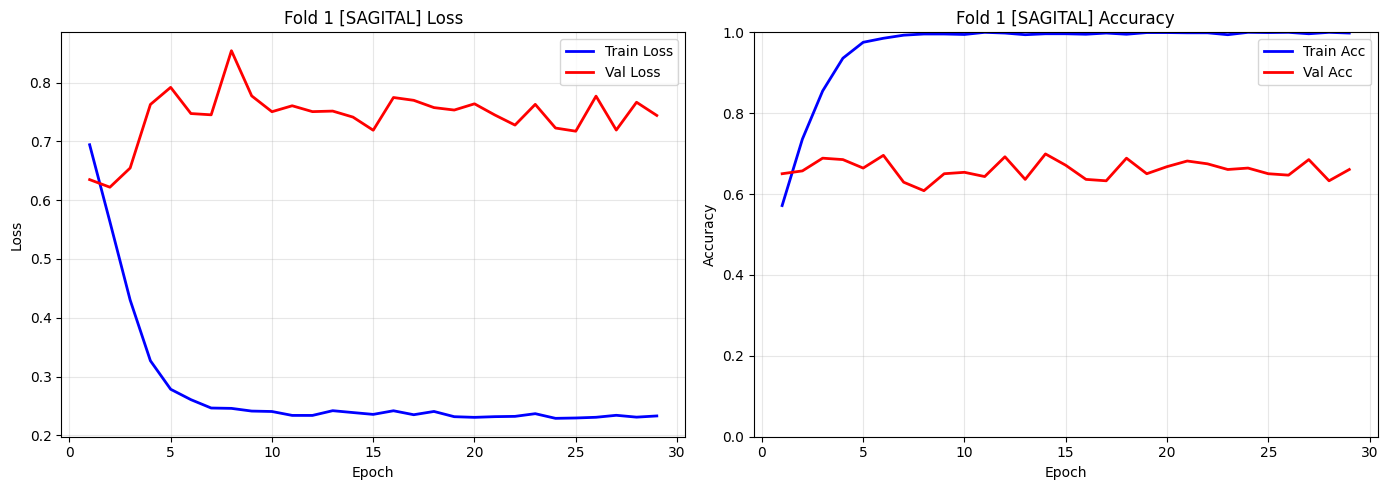


FOLD 1 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6993
  Precision     : 0.7050
  Recall        : 0.6993
  F1 Score      : 0.6962
  Per-Class F1  : CN=0.6614 | EMCI=0.7296 | Fark=0.0681 Normal
  Best Val Loss : 0.7415
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_1.pth

FOLD 2 [SAGITAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7044 | Train Acc: 0.5759 | Val Loss: 0.6407 | Val Acc: 0.5899 | Val mF1: 0.5837 | LR_bb: 5.00e-05
         Val tahmin: CN=150, EMCI=128
  Epoch 02 * | Train Loss: 0.5663 | Train Acc: 0.7261 | Val Loss: 0.6761 | Val Acc: 0.6151 | Val mF1: 0.6149 | LR_bb: 5.00e-05
 

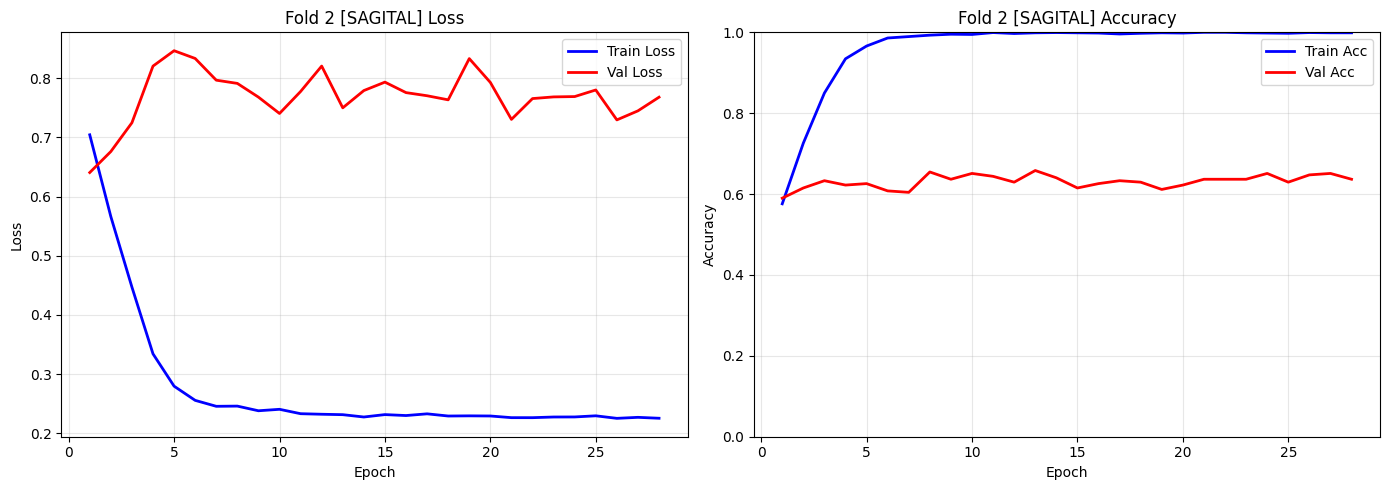


FOLD 2 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6583
  Precision     : 0.6807
  Recall        : 0.6583
  F1 Score      : 0.6602
  Per-Class F1  : CN=0.6735 | EMCI=0.6415 | Fark=0.0320 Normal
  Best Val Loss : 0.7500
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_2.pth

FOLD 3 [SAGITAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6983 | Train Acc: 0.5937 | Val Loss: 0.6234 | Val Acc: 0.6178 | Val mF1: 0.6109 | LR_bb: 5.00e-05
         Val tahmin: CN=181, EMCI=133
  Epoch 02 * | Train Loss: 0.5549 | Train Acc: 0.7446 | Val Loss: 0.6117 | Val Acc: 0.6561 | Val mF1: 0.6554 | LR_bb: 5.00e-05
 

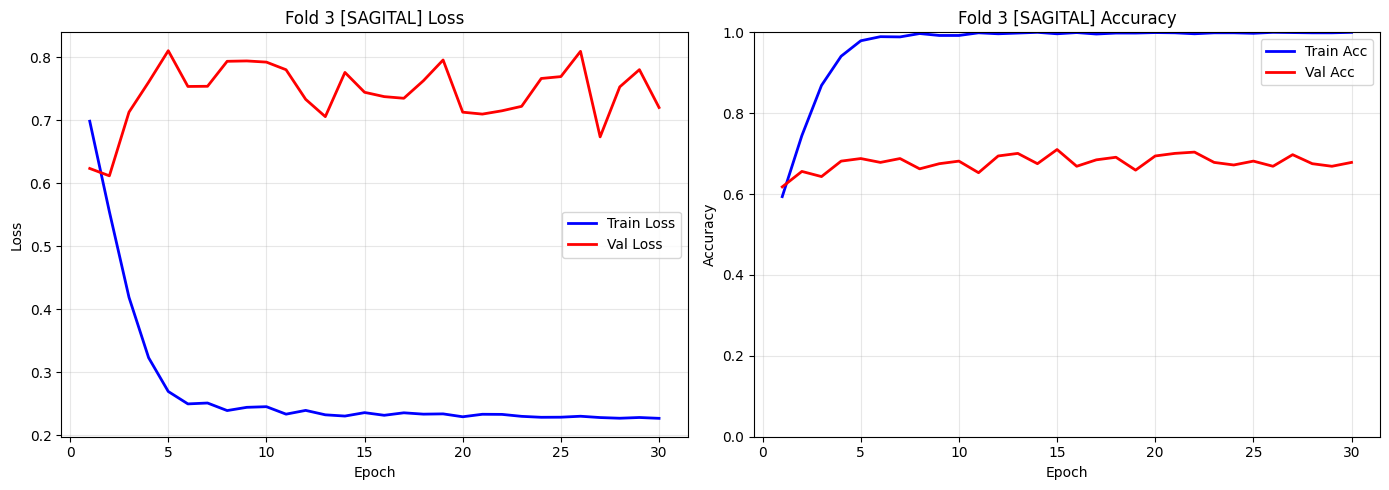


FOLD 3 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7102
  Precision     : 0.7104
  Recall        : 0.7102
  F1 Score      : 0.7103
  Per-Class F1  : CN=0.7393 | EMCI=0.6738 | Fark=0.0654 Normal
  Best Val Loss : 0.7442
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_3.pth

FOLD 4 [SAGITAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6968 | Train Acc: 0.5855 | Val Loss: 0.6083 | Val Acc: 0.6574 | Val mF1: 0.6526 | LR_bb: 5.00e-05
         Val tahmin: CN=100, EMCI=189
  Epoch 02 * | Train Loss: 0.5623 | Train Acc: 0.7331 | Val Loss: 0.6197 | Val Acc: 0.6574 | Val mF1: 0.6537 | LR_bb: 5.00e-05
 

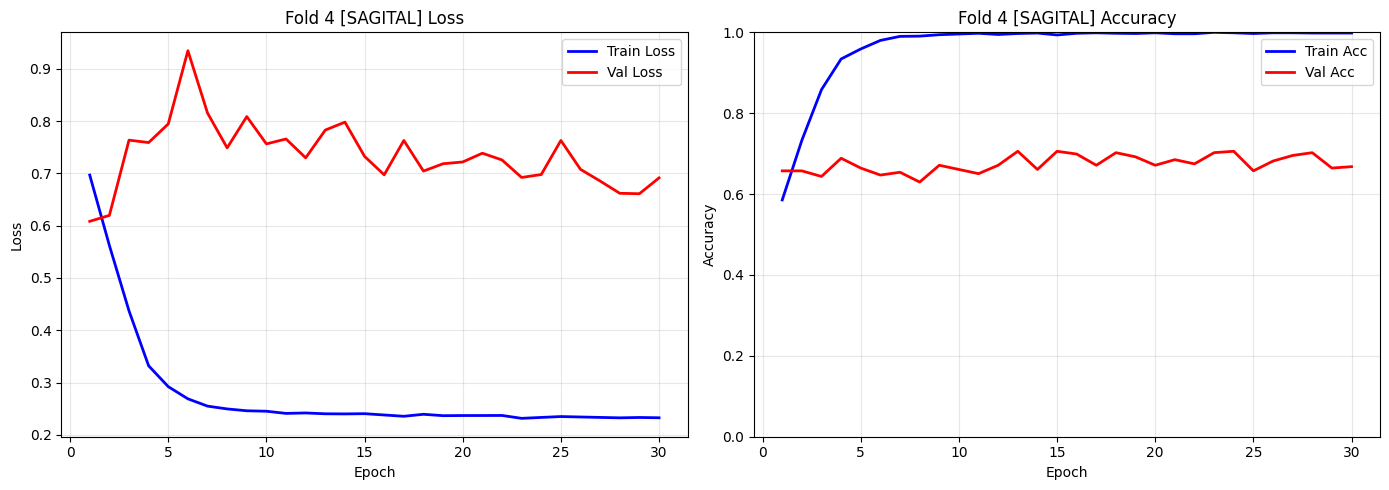


FOLD 4 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7059
  Precision     : 0.7146
  Recall        : 0.7059
  F1 Score      : 0.7057
  Per-Class F1  : CN=0.7038 | EMCI=0.7079 | Fark=0.0041 Normal
  Best Val Loss : 0.7325
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_4.pth

FOLD 5 [SAGITAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7099 | Train Acc: 0.5327 | Val Loss: 0.6486 | Val Acc: 0.6558 | Val mF1: 0.6502 | LR_bb: 5.00e-05
         Val tahmin: CN=121, EMCI=155
  Epoch 02   | Train Loss: 0.5914 | Train Acc: 0.7182 | Val Loss: 0.6680 | Val Acc: 0.6196 | Val mF1: 0.6169 | LR_bb: 5.00e-05
 

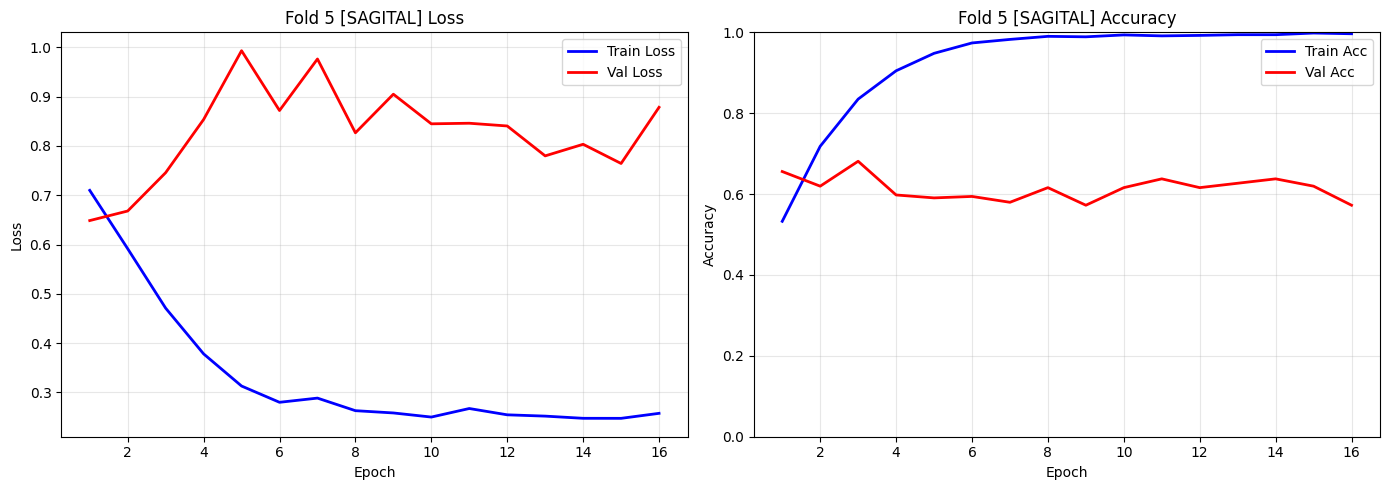


FOLD 5 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6558
  Precision     : 0.6561
  Recall        : 0.6558
  F1 Score      : 0.6560
  Per-Class F1  : CN=0.6058 | EMCI=0.6945 | Fark=0.0887 Normal
  Best Val Loss : 0.6486
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_5.pth

SAGITAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.699301 0.696203       0.741478
    2 0.658273 0.660174       0.749986
    3 0.710191 0.710295       0.744193
    4 0.705882 0.705720       0.732545
    5 0.655797 0.655958       0.648594
Ortalama Val Acc: 0.6859 +/- 0.0266
Sure: 38.8 dakika


In [ ]:
import time

sagital_klasoru = os.path.join(ANA_KLASOR, "Sagital")

print(f"EGITIM 1/3: SAGITAL")
print(f"Klasor: {sagital_klasoru}\n")

t0 = time.time()
sonuclar_sagital = duzlem_egit(tum_veriler, 'sagital', CONFIG, sagital_klasoru)
sure_sagital = time.time() - t0

df_sagital = pd.read_csv(os.path.join(sagital_klasoru, 'deney_sonuclari.csv'))
print(f"\nSAGITAL 5-FOLD VALIDATION SONUCLARI:")
print(df_sagital[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_sagital['val_acc'].mean():.4f} +/- {df_sagital['val_acc'].std():.4f}")
print(f"Sure: {sure_sagital/60:.1f} dakika")

EGITIM 2/3: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal


DUZLEM: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal

FOLD 1 [AKSIYAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7364 | Train Acc: 0.5340 | Val Loss: 0.6585 | Val Acc: 0.6364 | Val mF1: 0.6312 | LR_bb: 5.00e-05
         Val tahmin: CN=112, EMCI=174
  Epoch 02 * | Train Loss: 0.6023 | Train Acc: 0.6854 | Val Loss: 0.6509 | Val Acc: 0.6364 | Val mF1: 0.6364 | LR_bb: 5.00e-05
  Epoch 03 * | Train Loss: 0.4802 | Train Acc: 0.8163 | Val Loss: 0.6698 | Val Acc

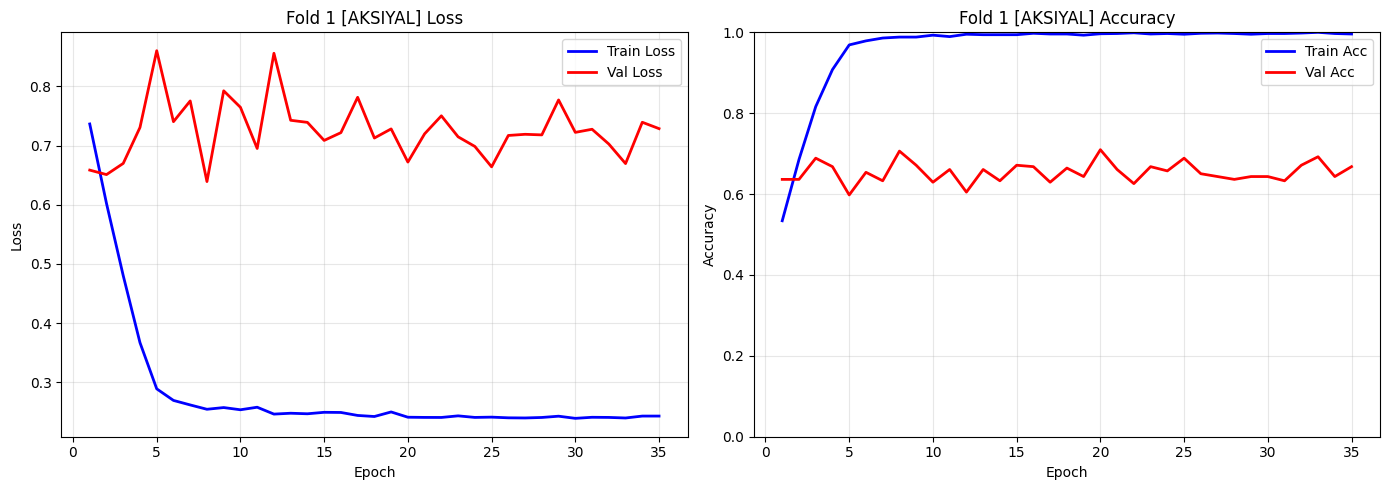


FOLD 1 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.7098
  Precision     : 0.7135
  Recall        : 0.7098
  F1 Score      : 0.7078
  Per-Class F1  : CN=0.6795 | EMCI=0.7348 | Fark=0.0553 Normal
  Best Val Loss : 0.6721
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal/aksiyal_fold_1.pth

FOLD 2 [AKSIYAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7034 | Train Acc: 0.5444 | Val Loss: 0.6533 | Val Acc: 0.6007 | Val mF1: 0.6003 | LR_bb: 5.00e-05
         Val tahmin: CN=107, EMCI=171
  Epoch 02 * | Train Loss: 0.5959 | Train Acc: 0.6916 | Val Loss: 0.6505 | Val Acc: 0.6043 | Val mF1: 0.6008 | LR_bb: 5.00e-05
 

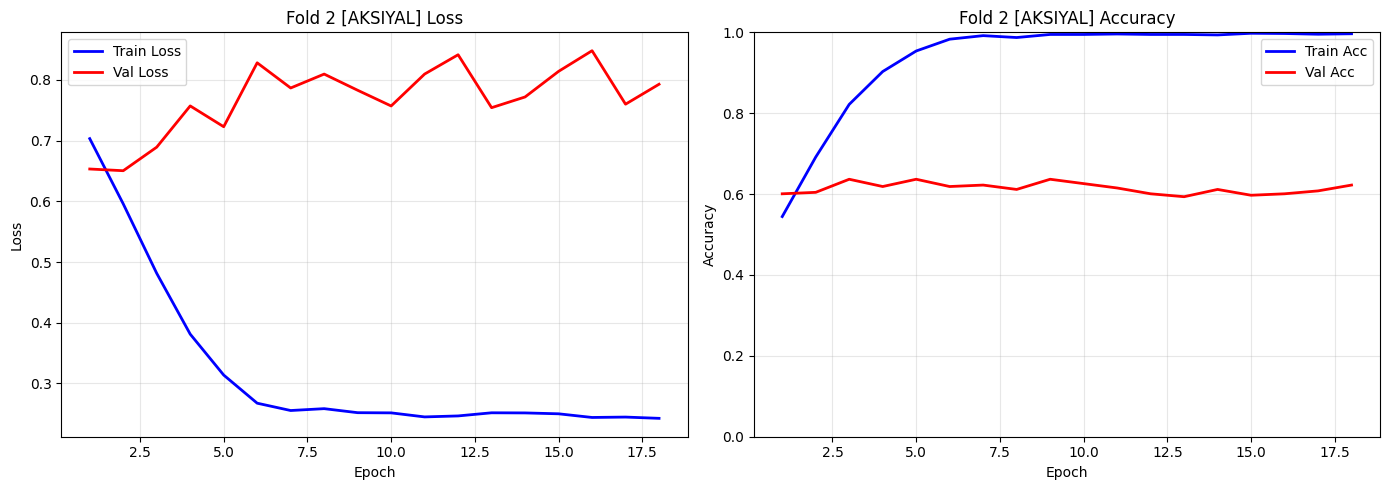


FOLD 2 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6367
  Precision     : 0.6970
  Recall        : 0.6367
  F1 Score      : 0.6316
  Per-Class F1  : CN=0.6130 | EMCI=0.6576 | Fark=0.0446 Normal
  Best Val Loss : 0.6894
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal/aksiyal_fold_2.pth

FOLD 3 [AKSIYAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7251 | Train Acc: 0.5328 | Val Loss: 0.6588 | Val Acc: 0.5701 | Val mF1: 0.5543 | LR_bb: 5.00e-05
         Val tahmin: CN=198, EMCI=116
  Epoch 02 * | Train Loss: 0.6088 | Train Acc: 0.6874 | Val Loss: 0.6880 | Val Acc: 0.6592 | Val mF1: 0.6580 | LR_bb: 5.00e-05
 

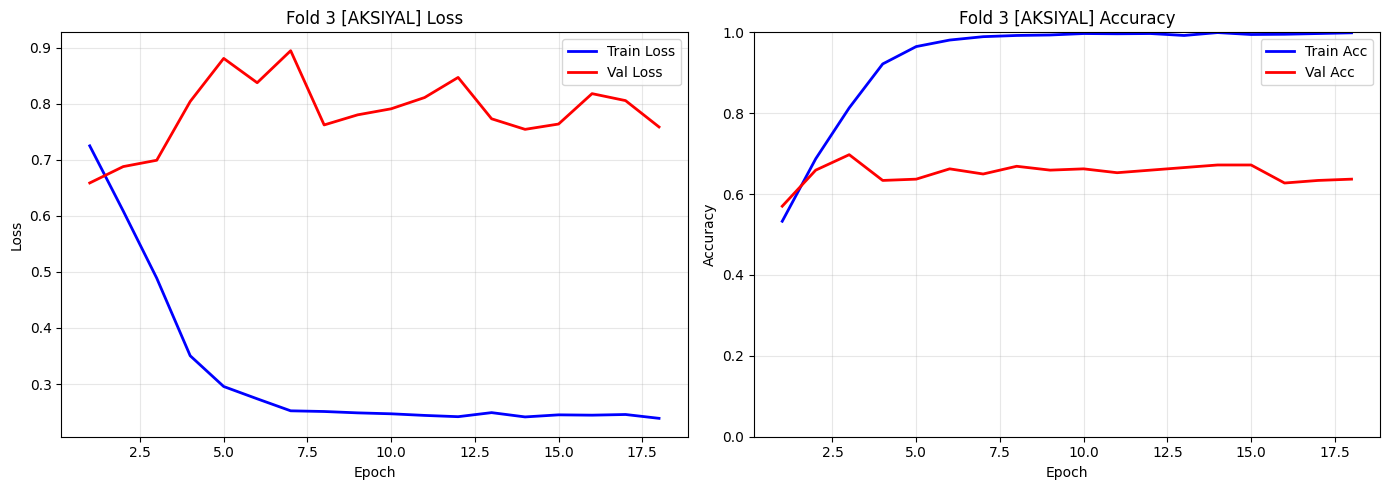


FOLD 3 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6975
  Precision     : 0.6959
  Recall        : 0.6975
  F1 Score      : 0.6954
  Per-Class F1  : CN=0.7383 | EMCI=0.6415 | Fark=0.0968 Normal
  Best Val Loss : 0.6993
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal/aksiyal_fold_3.pth

FOLD 4 [AKSIYAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7346 | Train Acc: 0.5309 | Val Loss: 0.6531 | Val Acc: 0.6401 | Val mF1: 0.6111 | LR_bb: 5.00e-05
         Val tahmin: CN=213, EMCI=76
  Epoch 02 * | Train Loss: 0.6124 | Train Acc: 0.6702 | Val Loss: 0.5902 | Val Acc: 0.7093 | Val mF1: 0.7088 | LR_bb: 5.00e-05
  

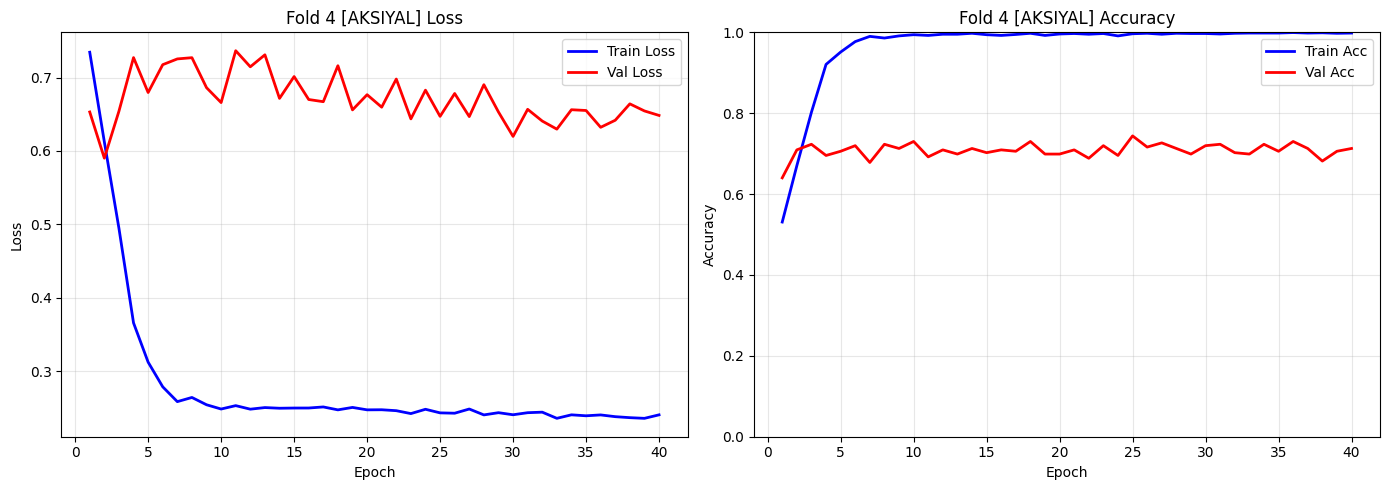


FOLD 4 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.7439
  Precision     : 0.7446
  Recall        : 0.7439
  F1 Score      : 0.7442
  Per-Class F1  : CN=0.7582 | EMCI=0.7279 | Fark=0.0302 Normal
  Best Val Loss : 0.6472
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal/aksiyal_fold_4.pth

FOLD 5 [AKSIYAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7128 | Train Acc: 0.5175 | Val Loss: 0.6820 | Val Acc: 0.5507 | Val mF1: 0.5505 | LR_bb: 5.00e-05
         Val tahmin: CN=162, EMCI=114
  Epoch 02 * | Train Loss: 0.6185 | Train Acc: 0.6470 | Val Loss: 0.6352 | Val Acc: 0.6486 | Val mF1: 0.6469 | LR_bb: 5.00e-05
 

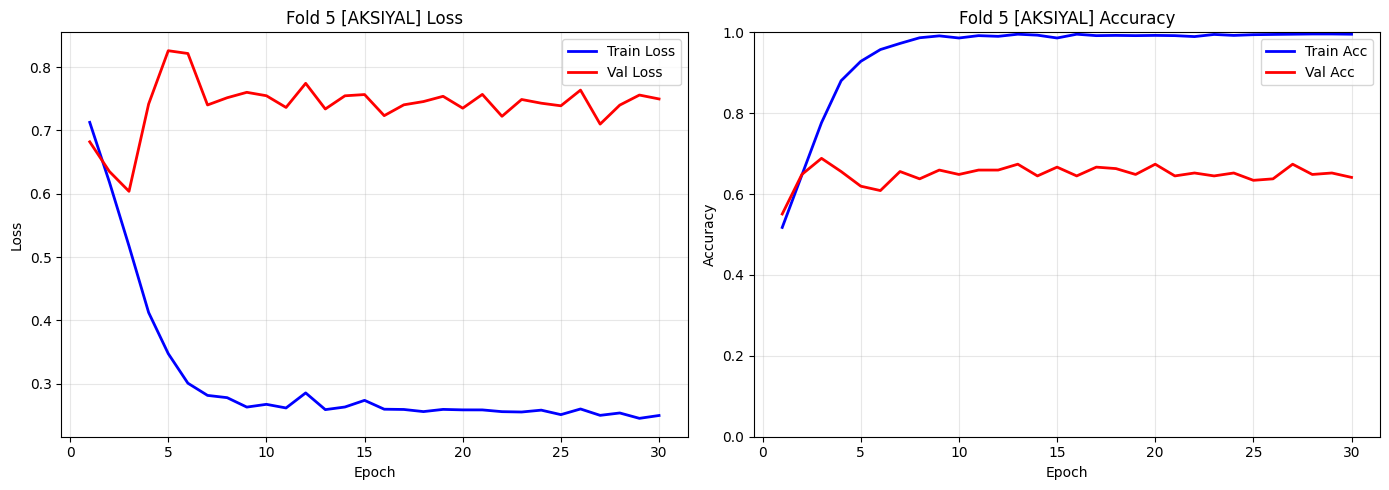


FOLD 5 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6667
  Precision     : 0.6878
  Recall        : 0.6667
  F1 Score      : 0.6670
  Per-Class F1  : CN=0.6642 | EMCI=0.6691 | Fark=0.0048 Normal
  Best Val Loss : 0.7567
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Aksiyal/aksiyal_fold_5.pth

AKSIYAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.709790 0.707760       0.672073
    2 0.636691 0.631637       0.689352
    3 0.697452 0.695449       0.699329
    4 0.743945 0.744154       0.647162
    5 0.666667 0.666964       0.756695
Ortalama Val Acc: 0.6909 +/- 0.0410
Sure: 41.2 dakika


In [ ]:
import time

aksiyal_klasoru = os.path.join(ANA_KLASOR, "Aksiyal")

print(f"EGITIM 2/3: AKSIYAL")
print(f"Klasor: {aksiyal_klasoru}\n")

t0 = time.time()
sonuclar_aksiyal = duzlem_egit(tum_veriler, 'aksiyal', CONFIG, aksiyal_klasoru)
sure_aksiyal = time.time() - t0

df_aksiyal = pd.read_csv(os.path.join(aksiyal_klasoru, 'deney_sonuclari.csv'))
print(f"\nAKSIYAL 5-FOLD VALIDATION SONUCLARI:")
print(df_aksiyal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_aksiyal['val_acc'].mean():.4f} +/- {df_aksiyal['val_acc'].std():.4f}")
print(f"Sure: {sure_aksiyal/60:.1f} dakika")

EGITIM 3/3: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal


DUZLEM: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal

FOLD 1 [KORONAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.7033 | Train Acc: 0.5528 | Val Loss: 0.6526 | Val Acc: 0.6119 | Val mF1: 0.5991 | LR_bb: 5.00e-05
         Val tahmin: CN=95, EMCI=191
  Epoch 02 * | Train Loss: 0.5778 | Train Acc: 0.7242 | Val Loss: 0.7019 | Val Acc: 0.6294 | Val mF1: 0.6275 | LR_bb: 5.00e-05
  Epoch 03   | Train Loss: 0.4621 | Train Acc: 0.8292 | Val Loss: 0.7216 | Val Acc:

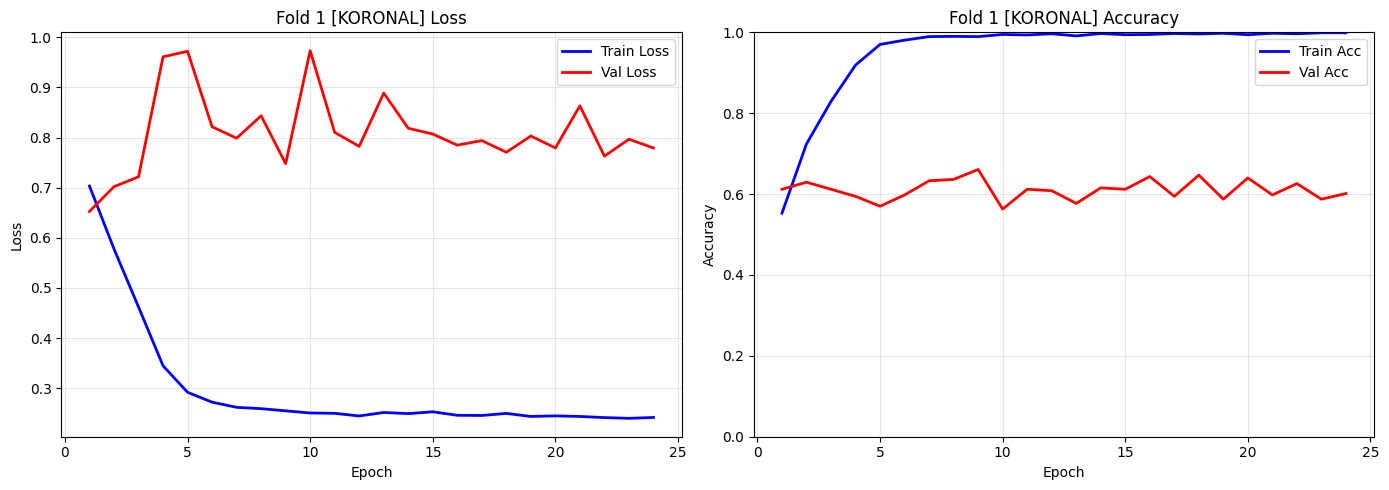


FOLD 1 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6608
  Precision     : 0.6609
  Recall        : 0.6608
  F1 Score      : 0.6605
  Per-Class F1  : CN=0.6447 | EMCI=0.6756 | Fark=0.0309 Normal
  Best Val Loss : 0.7479
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal/koronal_fold_1.pth

FOLD 2 [KORONAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6997 | Train Acc: 0.5707 | Val Loss: 0.6204 | Val Acc: 0.6439 | Val mF1: 0.5607 | LR_bb: 5.00e-05
         Val tahmin: CN=237, EMCI=41
  Epoch 02 * | Train Loss: 0.5597 | Train Acc: 0.7255 | Val Loss: 0.6070 | Val Acc: 0.7086 | Val mF1: 0.7086 | LR_bb: 5.00e-05
  

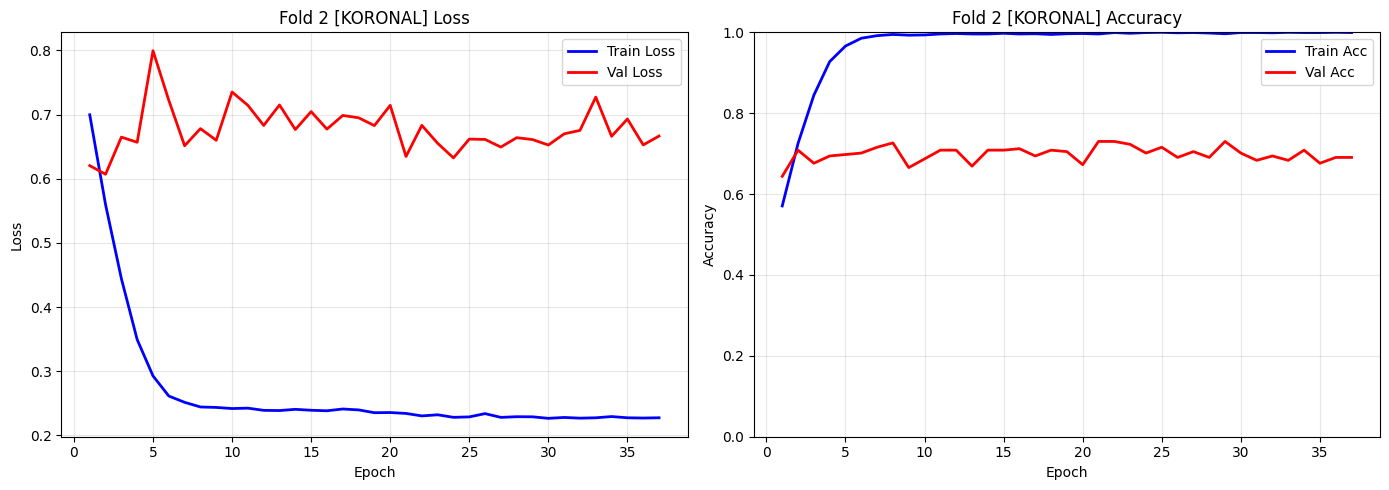


FOLD 2 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7302
  Precision     : 0.7762
  Recall        : 0.7302
  F1 Score      : 0.7297
  Per-Class F1  : CN=0.7273 | EMCI=0.7331 | Fark=0.0058 Normal
  Best Val Loss : 0.6832
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal/koronal_fold_2.pth

FOLD 3 [KORONAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6975 | Train Acc: 0.5794 | Val Loss: 0.7241 | Val Acc: 0.5669 | Val mF1: 0.5469 | LR_bb: 5.00e-05
         Val tahmin: CN=73, EMCI=241
  Epoch 02 * | Train Loss: 0.5769 | Train Acc: 0.7142 | Val Loss: 0.7040 | Val Acc: 0.6178 | Val mF1: 0.6177 | LR_bb: 5.00e-05
  

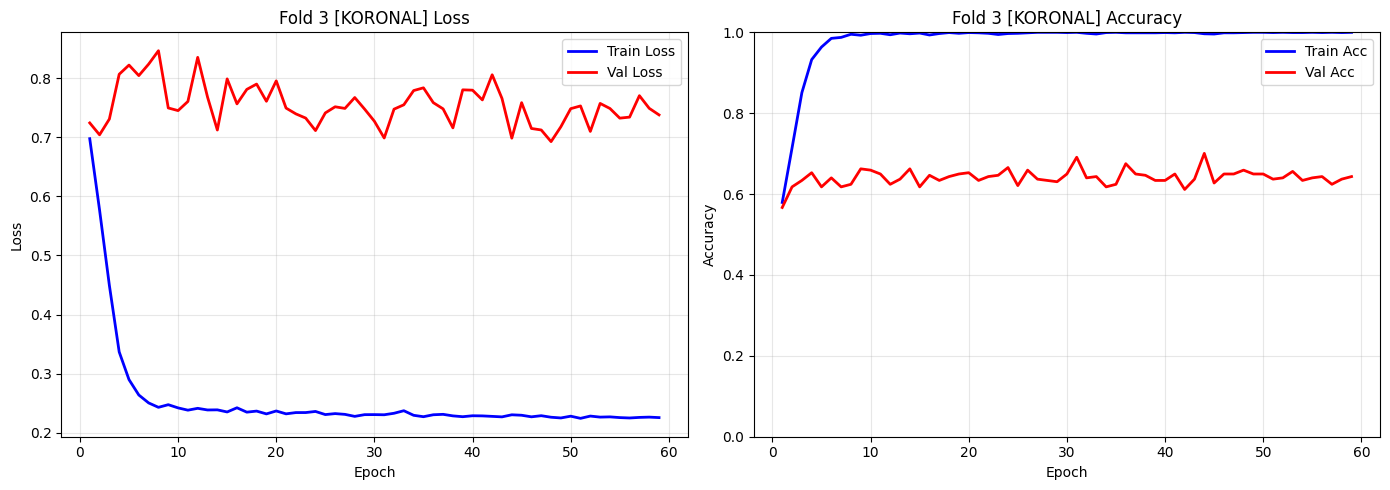


FOLD 3 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7006
  Precision     : 0.7119
  Recall        : 0.7006
  F1 Score      : 0.7014
  Per-Class F1  : CN=0.7099 | EMCI=0.6908 | Fark=0.0191 Normal
  Best Val Loss : 0.6984
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal/koronal_fold_3.pth

FOLD 4 [KORONAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6997 | Train Acc: 0.5585 | Val Loss: 0.6220 | Val Acc: 0.6332 | Val mF1: 0.6316 | LR_bb: 5.00e-05
         Val tahmin: CN=115, EMCI=174
  Epoch 02 * | Train Loss: 0.5971 | Train Acc: 0.7043 | Val Loss: 0.5893 | Val Acc: 0.7093 | Val mF1: 0.7028 | LR_bb: 5.00e-05
 

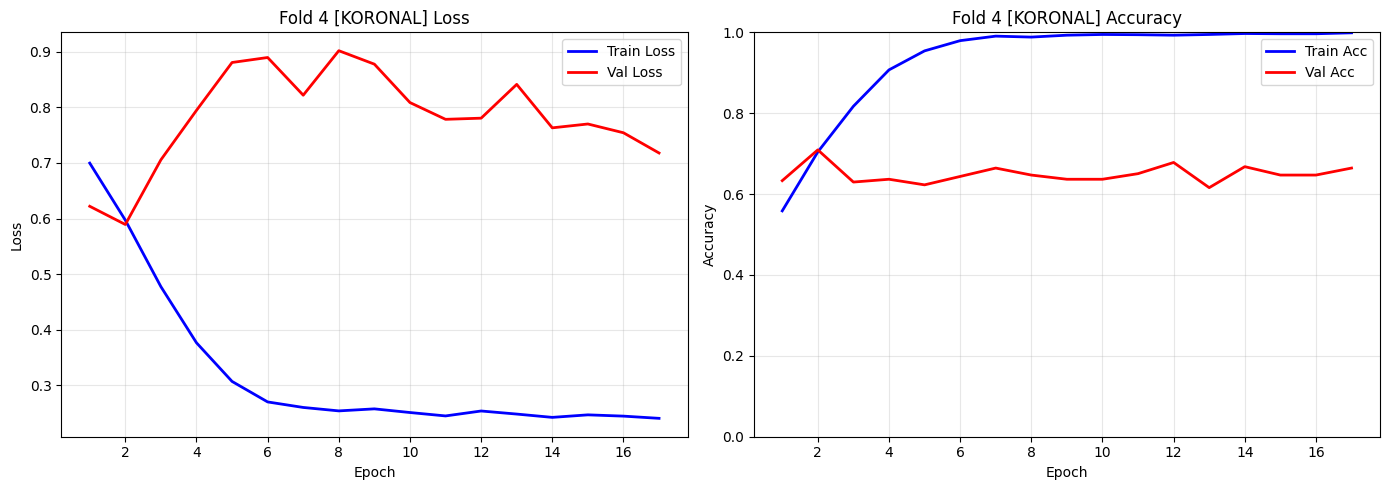


FOLD 4 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7093
  Precision     : 0.7678
  Recall        : 0.7093
  F1 Score      : 0.6995
  Per-Class F1  : CN=0.6585 | EMCI=0.7470 | Fark=0.0885 Normal
  Best Val Loss : 0.5893
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal/koronal_fold_4.pth

FOLD 5 [KORONAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6973 | Train Acc: 0.5554 | Val Loss: 0.6665 | Val Acc: 0.5507 | Val mF1: 0.5496 | LR_bb: 5.00e-05
         Val tahmin: CN=170, EMCI=106
  Epoch 02 * | Train Loss: 0.6009 | Train Acc: 0.6826 | Val Loss: 0.5800 | Val Acc: 0.6993 | Val mF1: 0.6678 | LR_bb: 5.00e-05
 

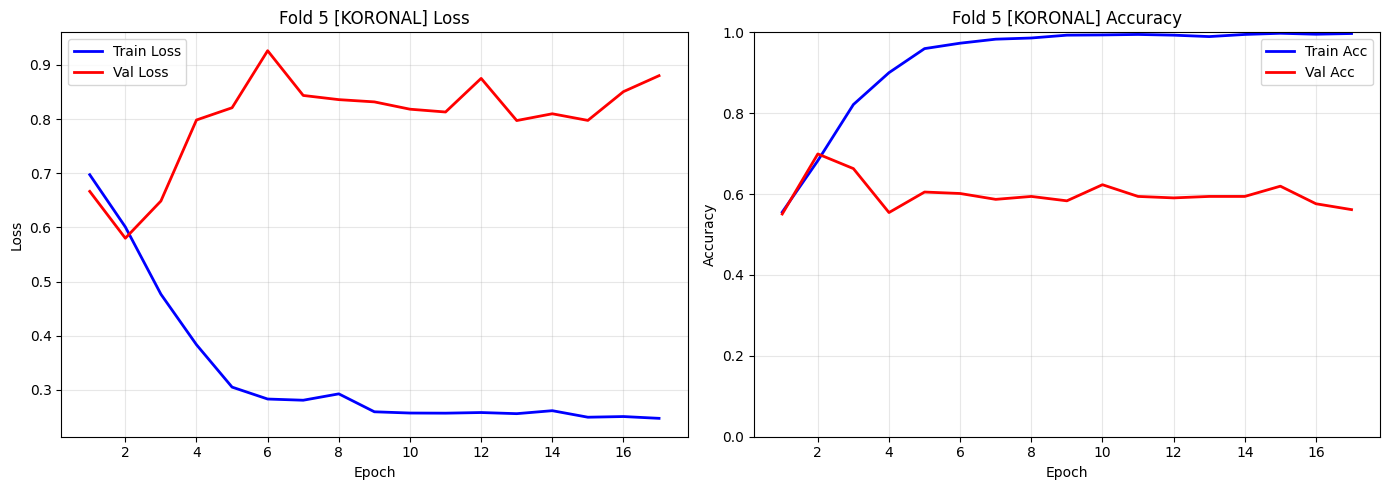


FOLD 5 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6993
  Precision     : 0.7139
  Recall        : 0.6993
  F1 Score      : 0.6811
  Per-Class F1  : CN=0.5654 | EMCI=0.7701 | Fark=0.2046 KONTROL ET
  Best Val Loss : 0.5800
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Koronal/koronal_fold_5.pth

KORONAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.660839 0.660461       0.747906
    2 0.730216 0.729703       0.683159
    3 0.700637 0.701427       0.698351
    4 0.709343 0.699549       0.589266
    5 0.699275 0.681110       0.580010
Ortalama Val Acc: 0.7001 +/- 0.0252
Sure: 44.4 dakika


In [ ]:
import time

koronal_klasoru = os.path.join(ANA_KLASOR, "Koronal")

print(f"EGITIM 3/3: KORONAL")
print(f"Klasor: {koronal_klasoru}\n")

t0 = time.time()
sonuclar_koronal = duzlem_egit(tum_veriler, 'koronal', CONFIG, koronal_klasoru)
sure_koronal = time.time() - t0

df_koronal = pd.read_csv(os.path.join(koronal_klasoru, 'deney_sonuclari.csv'))
print(f"\nKORONAL 5-FOLD VALIDATION SONUCLARI:")
print(df_koronal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_koronal['val_acc'].mean():.4f} +/- {df_koronal['val_acc'].std():.4f}")
print(f"Sure: {sure_koronal/60:.1f} dakika")

TOPLU VALIDATION SONUCLARI (Per-Plane)

--- SAGITAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.699301 0.696203   0.661417     0.729560       0.741478
    2 0.658273 0.660174   0.673540     0.641509       0.749986
    3 0.710191 0.710295   0.739255     0.673835       0.744193
    4 0.705882 0.705720   0.703833     0.707904       0.732545
    5 0.655797 0.655958   0.605809     0.694534       0.648594
  Ortalama Val Acc : 0.6859 +/- 0.0266
  Ortalama Val F1  : 0.6857
  CN F1 / EMCI F1  : 0.6768 / 0.6895

--- AKSIYAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.709790 0.707760   0.679537     0.734824       0.672073
    2 0.636691 0.631637   0.613027     0.657627       0.689352
    3 0.697452 0.695449   0.738292     0.641509       0.699329
    4 0.743945 0.744154   0.758170     0.727941       0.647162
    5 0.666667 0.666964   0.664234     0.669065       0.756695
  Ortalama Val Acc : 0.6909 +/- 0.0410
  Ortalama Val F1  : 0.6892


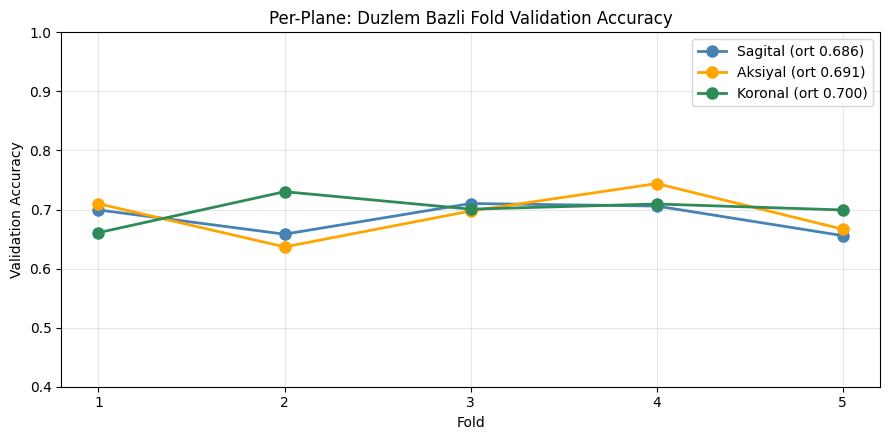

In [ ]:
# ===== TOPLU VALIDATION OZETI (3 duzlem x 5 fold) =====
import pandas as pd, os

# Modeller baska bir oturumda egitildiyse ANA_KLASOR'u elle sabitle:

duzlemler = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}

tum_dfler = []
print("="*70)
print("TOPLU VALIDATION SONUCLARI (Per-Plane)")
print("="*70)

for ad, yol in duzlemler.items():
    if not os.path.exists(yol):
        print(f"\n[{ad}] CSV bulunamadi ({yol}) - bu duzlem egitilmemis olabilir.")
        continue
    df = pd.read_csv(yol)
    df['duzlem'] = ad
    tum_dfler.append(df)

    print(f"\n--- {ad.upper()} ---")
    print(df[['fold', 'val_acc', 'val_f1', 'val_f1_cn', 'val_f1_emci', 'best_val_loss']].to_string(index=False))
    print(f"  Ortalama Val Acc : {df['val_acc'].mean():.4f} +/- {df['val_acc'].std():.4f}")
    print(f"  Ortalama Val F1  : {df['val_f1'].mean():.4f}")
    print(f"  CN F1 / EMCI F1  : {df['val_f1_cn'].mean():.4f} / {df['val_f1_emci'].mean():.4f}")

if tum_dfler:
    hepsi = pd.concat(tum_dfler, ignore_index=True)

    print("\n" + "="*70)
    print("DUZLEM BAZLI OZET TABLOSU")
    print("="*70)
    ozet = hepsi.groupby('duzlem').agg(
        val_acc_ort=('val_acc', 'mean'),
        val_acc_std=('val_acc', 'std'),
        val_f1_ort=('val_f1', 'mean'),
        cn_f1=('val_f1_cn', 'mean'),
        emci_f1=('val_f1_emci', 'mean'),
    ).round(4)
    print(ozet.to_string())

    print("\n" + "="*70)
    print("GENEL ORTALAMA (15 model = 3 duzlem x 5 fold)")
    print("="*70)
    print(f"  Val Accuracy : {hepsi['val_acc'].mean():.4f} +/- {hepsi['val_acc'].std():.4f}")
    print(f"  Val F1       : {hepsi['val_f1'].mean():.4f} +/- {hepsi['val_f1'].std():.4f}")
    print(f"  CN F1        : {hepsi['val_f1_cn'].mean():.4f}")
    print(f"  EMCI F1      : {hepsi['val_f1_emci'].mean():.4f}")

    # Gorsel: duzlem bazli fold accuracy
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4.5))
    renkler = {'Sagital': 'steelblue', 'Aksiyal': 'orange', 'Koronal': 'seagreen'}
    for ad in ['Sagital', 'Aksiyal', 'Koronal']:
        d = hepsi[hepsi['duzlem'] == ad]
        if len(d) == 0: continue
        ax.plot(d['fold'], d['val_acc'], 'o-', label=f"{ad} (ort {d['val_acc'].mean():.3f})",
                color=renkler[ad], lw=2, markersize=8)
    ax.set_xlabel('Fold'); ax.set_ylabel('Validation Accuracy')
    ax.set_title('Per-Plane: Duzlem Bazli Fold Validation Accuracy')
    ax.set_xticks([1,2,3,4,5]); ax.set_ylim([0.4, 1.0])
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(ANA_KLASOR, 'toplu_val_accuracy.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\nHic CSV bulunamadi. Once egitimi calistir veya ANA_KLASOR'u dogru klasore sabitle.")

TEST seti: 296 seans  (CN=148, EMCI=148)

[SAGITAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_1.pth)
  fold 2 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_2.pth)
  fold 3 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_3.pth)
  fold 4 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_4.pth)
  fold 5 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/Sagital/sagital_fold_5.pth)

[AKSIYAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YA

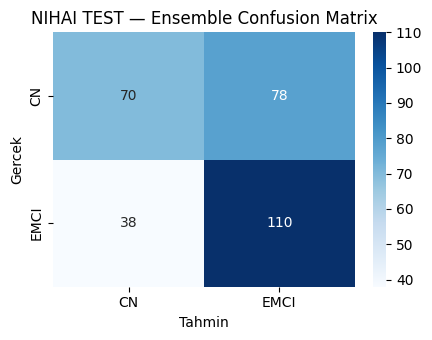

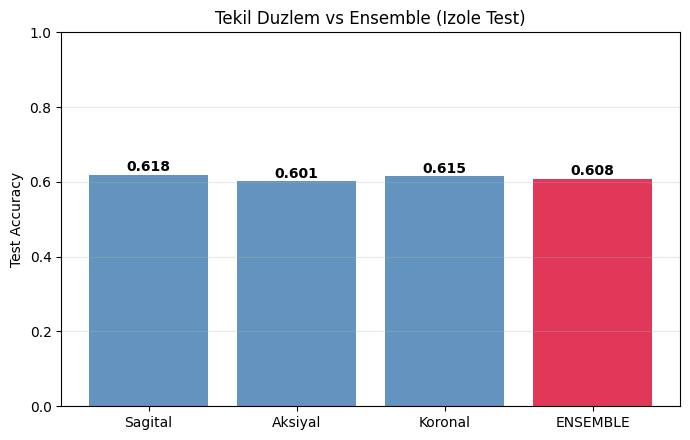


Kaydedildi: final_test_tahminler.csv, final_test_ozet.csv
Bitti.


In [ ]:
# ============================================================
# NIHAI TEST: izole test seti + 15 model agirlikli ensemble
# ============================================================
import numpy as np
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42'


# --- 1) Izole test verisini oku (train ile AYNI yapida) ---
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]

test_veriler = veri_listesi_olustur(test_config)
n_cn_te   = sum(1 for x in test_veriler if x['etiket'] == 0)
n_emci_te = sum(1 for x in test_veriler if x['etiket'] == 1)
print(f"TEST seti: {len(test_veriler)} seans  (CN={n_cn_te}, EMCI={n_emci_te})")
assert len(test_veriler) > 0, "Test seti bos! kaynak_CN_test / kaynak_EMCI_test yollarini kontrol et."

# Gercek etiket sozlugu: sid -> etiket
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# --- 2) Ensemble agirliklari (degistirilebilir) ---
DUZLEM_AGIRLIK = {'sagital': 1.0, 'aksiyal': 1.0, 'koronal': 1.0}

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# --- 3) Tahmin yardimci fonksiyonu (seans_id ile birlikte) ---
def tahmin_al(model, loader):
    model.eval()
    sids_all, probs_all = [], []
    with torch.no_grad():
        for sids, slices, lbls in loader:
            slices = slices.to(DEVICE)
            logits = model(slices)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            sids_all.extend(list(sids))
            probs_all.extend(probs.tolist())
    return sids_all, probs_all

# --- 4) Her duzlem icin 5 fold modelin olasiligini ortala ---
# plane_avg[duzlem][sid] = ortalama [prob_cn, prob_emci]
plane_avg = {}

for duzlem, klasor in DUZLEM_KLASOR.items():
    print(f"\n[{duzlem.upper()}] 5 fold modeli test ediliyor...")
    test_loader = loader_olustur(test_veriler, duzlem, CONFIG, shuffle=False)

    toplam = {}   # sid -> np.array([p_cn, p_emci]) toplam
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{duzlem}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2))
            toplam[sid] += np.array(pr)
        print(f"  fold {fold} tamam ({m_path})")
        del model
        torch.cuda.empty_cache()

    plane_avg[duzlem] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# --- 5) Agirlikli ensemble (3 duzlem) ---
toplam_agirlik = sum(DUZLEM_AGIRLIK.values())
ortak_sid = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
print(f"\nUc duzlemde de tahmin edilen ortak seans: {len(ortak_sid)}")

y_true, y_pred = [], []
y_pred_duzlem = {d: [] for d in DUZLEM_KLASOR}
kayit = []

for sid in sorted(ortak_sid):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += DUZLEM_AGIRLIK[d] * plane_avg[d][sid]
    fused /= toplam_agirlik

    pred = int(np.argmax(fused))
    true = sid_true[sid]
    y_true.append(true)
    y_pred.append(pred)

    satir = {'seans_id': sid,
             'gercek': 'CN' if true == 0 else 'EMCI',
             'ens_prob_cn': fused[0], 'ens_prob_emci': fused[1],
             'ensemble': 'CN' if pred == 0 else 'EMCI'}
    for d in DUZLEM_KLASOR:
        dp = int(np.argmax(plane_avg[d][sid]))
        y_pred_duzlem[d].append(dp)
        satir[d] = 'CN' if dp == 0 else 'EMCI'
    satir['dogru_mu'] = (true == pred)
    kayit.append(satir)

# --- 6) Metrikler ---
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)

print(f"\n{'='*70}")
print("NIHAI TEST SONUCLARI (Agirlikli Ensemble)")
print(f"{'='*70}")
print(f"Agirliklar    : {DUZLEM_AGIRLIK}")
print(f"Test seans    : {len(y_true)}")
print(f"\nTekil duzlem test accuracy:")
for d in DUZLEM_KLASOR:
    print(f"  {d.capitalize():9s}: {accuracy_score(y_true, y_pred_duzlem[d]):.4f}")
print(f"\n  ENSEMBLE Accuracy : {acc:.4f}")
print(f"  Precision         : {p:.4f}")
print(f"  Recall            : {r:.4f}")
print(f"  F1 Score          : {f:.4f}")
print(f"  Per-Class F1      : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")

print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

# --- 7) Confusion matrix ---
plt.figure(figsize=(4.5, 3.5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'EMCI'], yticklabels=['CN', 'EMCI'])
plt.title("NIHAI TEST — Ensemble Confusion Matrix")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_confusion_matrix.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 8) Tekil duzlem vs ensemble grafigi ---
fig, axg = plt.subplots(figsize=(7, 4.5))
isimler = [d.capitalize() for d in DUZLEM_KLASOR] + ['ENSEMBLE']
degerler = [accuracy_score(y_true, y_pred_duzlem[d]) for d in DUZLEM_KLASOR] + [acc]
renkler = ['steelblue']*3 + ['crimson']
axg.bar(isimler, degerler, color=renkler, alpha=0.85)
for i, v in enumerate(degerler):
    axg.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
axg.set_ylabel('Test Accuracy'); axg.set_ylim([0, 1])
axg.set_title('Tekil Duzlem vs Ensemble (Izole Test)')
axg.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_karsilastirma.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 9) Kayit ---
df_kayit = pd.DataFrame(kayit)
df_kayit.to_csv(os.path.join(ANA_KLASOR, 'final_test_tahminler.csv'), index=False)
pd.DataFrame([{
    'agirlik_sag': DUZLEM_AGIRLIK['sagital'],
    'agirlik_ax' : DUZLEM_AGIRLIK['aksiyal'],
    'agirlik_kor': DUZLEM_AGIRLIK['koronal'],
    'test_acc': acc, 'precision': p, 'recall': r, 'f1': f,
    'f1_cn': f_pc[0], 'f1_emci': f_pc[1], 'n_test': len(y_true)
}]).to_csv(os.path.join(ANA_KLASOR, 'final_test_ozet.csv'), index=False)

print(f"\nKaydedildi: final_test_tahminler.csv, final_test_ozet.csv")
print("Bitti.")

In [ ]:
# --- sonuclari sakla (grafik icin) ---
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
for d in DUZLEM_KLASOR:
    SONUCLAR['duzlem'][d.capitalize()] = accuracy_score(y_true, y_pred_duzlem[d])
SONUCLAR['strateji']['3-duzlem\nesit ensemble'] = acc

  Sagital   val_acc ort: 0.6859
  Aksiyal   val_acc ort: 0.6909
  Koronal   val_acc ort: 0.7001

VALIDATION'da en iyi duzlem: KORONAL  (0.7001)

EN IYI DUZLEM (KORONAL) 5-FOLD ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6149
   Precision    : 0.6341 | Recall: 0.6149 | F1: 0.6006
   Per-Class F1 : CN=0.5250 | EMCI=0.6761

              precision    recall  f1-score   support

          CN       0.68      0.43      0.53       148
        EMCI       0.58      0.80      0.68       148

    accuracy                           0.61       296
   macro avg       0.63      0.61      0.60       296
weighted avg       0.63      0.61      0.60       296



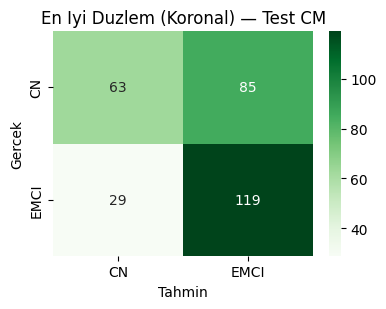

In [ ]:
# ===== EK HUCRE A: VALIDATION'da en iyi DUZLEMI sec, 5-fold ensemble test =====
import numpy as np, os

# Modeller baska oturumda egitildiyse dogru klasoru sabitle:
ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her duzlemin VALIDATION ortalamasini oku, en iyisini sec (TEST'e gore DEGIL)
val_ort = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    val_ort[d] = dfv['val_acc'].mean()
    print(f"  {d.capitalize():9s} val_acc ort: {val_ort[d]:.4f}")
en_iyi_duzlem = max(val_ort, key=val_ort.get)
print(f"\nVALIDATION'da en iyi duzlem: {en_iyi_duzlem.upper()}  ({val_ort[en_iyi_duzlem]:.4f})\n")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Sadece o duzlemin 5 fold modelini ortala
klasor = DUZLEM_KLASOR[en_iyi_duzlem]
test_loader = loader_olustur(test_veriler, en_iyi_duzlem, CONFIG, shuffle=False)
toplam = {}
for fold in range(1, CONFIG['k_fold'] + 1):
    m_path = os.path.join(klasor, f'{en_iyi_duzlem}_fold_{fold}.pth')
    model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, probs = tahmin_al(model, test_loader)
    for sid, pr in zip(sids, probs):
        toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
    del model; torch.cuda.empty_cache()
avg = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(avg.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(avg[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"{'='*60}\nEN IYI DUZLEM ({en_iyi_duzlem.upper()}) 5-FOLD ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title(f"En Iyi Duzlem ({en_iyi_duzlem.capitalize()}) — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['Val-agirlikli\nensemble'] = acc

Duzlem agirliklari (validation'dan):
   Sagital  : 0.322
   Aksiyal  : 0.331
   Koronal  : 0.347

VAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6081
   Precision    : 0.6166 | Recall: 0.6081 | F1: 0.6008
   Per-Class F1 : CN=0.5469 | EMCI=0.6548

              precision    recall  f1-score   support

          CN       0.65      0.47      0.55       148
        EMCI       0.59      0.74      0.65       148

    accuracy                           0.61       296
   macro avg       0.62      0.61      0.60       296
weighted avg       0.62      0.61      0.60       296



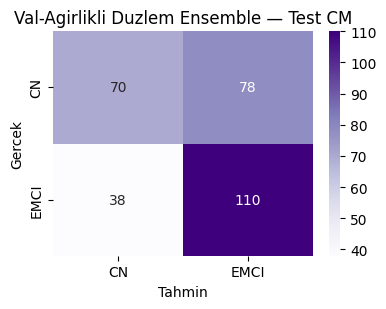

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.073
   Aksiyal   fold 2: 0.047
   Aksiyal   fold 3: 0.068
   Aksiyal   fold 4: 0.085
   Aksiyal   fold 5: 0.058
   Koronal   fold 1: 0.056
   Koronal   fold 2: 0.080
   Koronal   fold 3: 0.070
   Koronal   fold 4: 0.073
   Koronal   fold 5: 0.069
   Sagital   fold 1: 0.069
   Sagital   fold 2: 0.055
   Sagital   fold 3: 0.073
   Sagital   fold 4: 0.071
   Sagital   fold 5: 0.054

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6081
   Precision    : 0.6166 | Recall: 0.6081 | F1: 0.6008
   Per-Class F1 : CN=0.5469 | EMCI=0.6548

              precision    recall  f1-score   support

          CN       0.65      0.47      0.55       148
        EMCI       0.59      0.74      0.65       148

    accuracy                           0.61       296
   macro avg       0.62      0.61      0.60       296
weighted avg       0.62      0.61      0.60       296



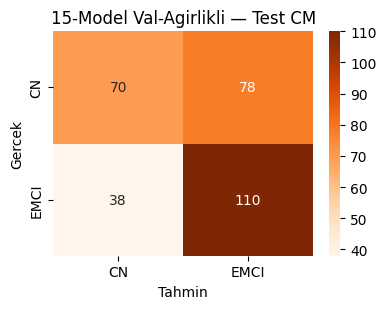

In [ ]:
# ===== EK HUCRE B: VALIDATION accuracy ile DUZLEM-AGIRLIKLI ensemble =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Agirliklar VALIDATION'dan: (val_acc - 0.5) ile zayif duzlem otomatik kisilir
agirlik = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    agirlik[d] = max(dfv['val_acc'].mean() - 0.5, 0.0)
toplam_ag = sum(agirlik.values())
agirlik = {d: v / toplam_ag for d, v in agirlik.items()}
print("Duzlem agirliklari (validation'dan):")
for d, w in agirlik.items():
    print(f"   {d.capitalize():9s}: {w:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Her duzlemin 5-fold ortalamasini al
plane_avg = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    toplam = {}
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
        del model; torch.cuda.empty_cache()
    plane_avg[d] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Agirlikli birlesim
ortak = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
y_true, y_pred = [], []
for sid in sorted(ortak):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += agirlik[d] * plane_avg[d][sid]
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(fused)))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\nVAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Purples',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("Val-Agirlikli Duzlem Ensemble — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['15-model\nagirlikli'] = acc

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.073
   Aksiyal   fold 2: 0.047
   Aksiyal   fold 3: 0.068
   Aksiyal   fold 4: 0.085
   Aksiyal   fold 5: 0.058
   Koronal   fold 1: 0.056
   Koronal   fold 2: 0.080
   Koronal   fold 3: 0.070
   Koronal   fold 4: 0.073
   Koronal   fold 5: 0.069
   Sagital   fold 1: 0.069
   Sagital   fold 2: 0.055
   Sagital   fold 3: 0.073
   Sagital   fold 4: 0.071
   Sagital   fold 5: 0.054

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6081
   Precision    : 0.6166 | Recall: 0.6081 | F1: 0.6008
   Per-Class F1 : CN=0.5469 | EMCI=0.6548

              precision    recall  f1-score   support

          CN       0.65      0.47      0.55       148
        EMCI       0.59      0.74      0.65       148

    accuracy                           0.61       296
   macro avg       0.62      0.61      0.60       296
weighted avg       0.62      0.61      0.60       296



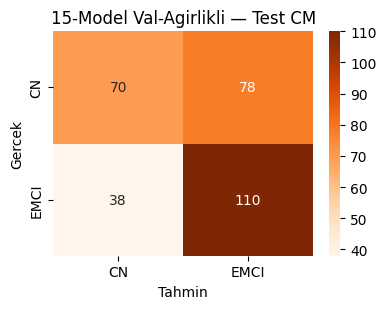

In [ ]:
# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

In [ ]:
try: SONUCLAR
except NameError: SONUCLAR = {'duzlem': {}, 'strateji': {}}
SONUCLAR['strateji']['15-model\nagirlikli'] = acc

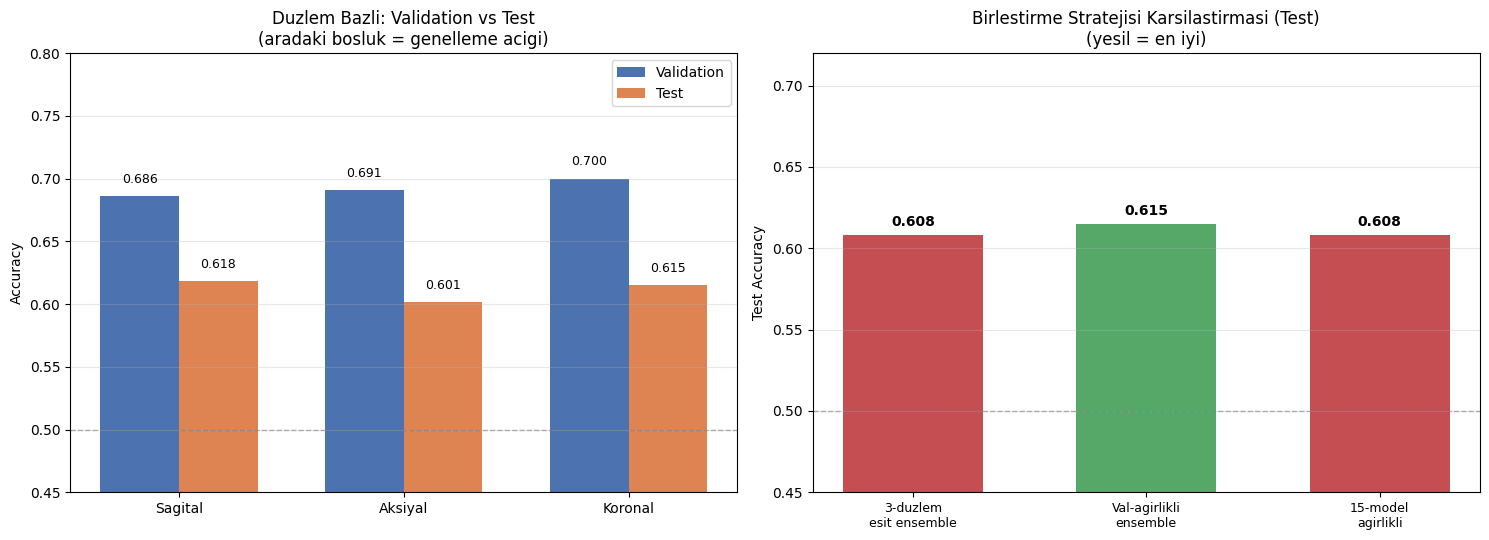

Kaydedildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_YOL2_2026_06_06_14_42/val_test_karsilastirma.png


In [ ]:
# ===== GRAFIK: Val vs Test + Strateji Karsilastirmasi (otomatik) =====
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, os

# Validation accuracy'leri CSV'den otomatik oku
duzlem_klasor = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}
val_acc = {}
for ad, yol in duzlem_klasor.items():
    try: val_acc[ad] = pd.read_csv(yol)['val_acc'].mean()
    except Exception: val_acc[ad] = np.nan

# Test sonuclari SONUCLAR sozlugunden (test hucrelerinde otomatik dolduruldu)
test_acc_duzlem = SONUCLAR['duzlem']
strateji_test   = SONUCLAR['strateji']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: Duzlem bazli Val vs Test
duzlemler = [d for d in ['Sagital','Aksiyal','Koronal'] if d in test_acc_duzlem]
x = np.arange(len(duzlemler)); w = 0.35
vd = [val_acc.get(d, np.nan) for d in duzlemler]
td = [test_acc_duzlem[d] for d in duzlemler]
b1 = ax1.bar(x - w/2, vd, w, label='Validation', color='#4C72B0')
b2 = ax1.bar(x + w/2, td, w, label='Test', color='#DD8452')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax1.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.3f}',
                     ha='center', va='bottom', fontsize=9)
ax1.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(duzlemler)
ax1.set_ylabel('Accuracy'); ax1.set_ylim([0.45, 0.80])
ax1.set_title('Duzlem Bazli: Validation vs Test\n(aradaki bosluk = genelleme acigi)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Panel 2: Strateji bazli Test
stratejiler = list(strateji_test.keys())
ts = [strateji_test[s] for s in stratejiler]
renkler = ['#55A868' if v == max(ts) else '#C44E52' for v in ts]
bars = ax2.bar(stratejiler, ts, color=renkler, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+0.004, f'{h:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
ax2.set_ylabel('Test Accuracy'); ax2.set_ylim([0.45, 0.72])
ax2.set_title('Birlestirme Stratejisi Karsilastirmasi (Test)\n(yesil = en iyi)')
ax2.grid(axis='y', alpha=0.3); plt.setp(ax2.get_xticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'val_test_karsilastirma.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Kaydedildi:", os.path.join(ANA_KLASOR, 'val_test_karsilastirma.png'))